In [1]:
import ee
import geemap
import geemap.colormaps as cm
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon, Point
import os

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Windows / Colab 겸용: 한글 폰트 설정
font_path = None
candidates = [
    r"C:\Windows\Fonts\malgun.ttf",  # Windows 맑은 고딕
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",  # Colab/리눅스 나눔고딕
]
for p in candidates:
    if os.path.exists(p):
        font_path = p
        break
if font_path:
    font = fm.FontProperties(fname=font_path)
    plt.rc("font", family=font.get_name())
else:
    plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

#취약계층 관련 csv 파일 불러오기
- 고령,어린이 인구
- 기초 수급자
- 독거노인

In [3]:
import os

base = ".."

for root, dirs, files in os.walk(base):
    for f in files:
        if "등록인구" in f:
            print(os.path.join(root, f))


..\data_processed\raw\vulnerable\서울시_등록인구.csv


In [4]:
base_path="../data_processed/raw/vulnerable/"
file_path = "서울시_등록인구.csv"
df_ppl = pd.read_csv(base_path + file_path)

In [5]:
df_ppl

,구별,동별,0~9세,65세이상
0,종로구,사직동,389,1963
1,종로구,삼청동,93,641
2,종로구,부암동,337,2033
3,종로구,평창동,885,4019
4,종로구,무악동,473,1587
...,...,...,...,...
423,강동구,천호2동,1469,7224
424,강동구,길동,2136,10281
425,강동구,강일동,2996,6922
426,강동구,상일1동,4026,5840


In [6]:
df_ppl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   구별      428 non-null    object
 1   동별      428 non-null    object
 2   0~9세    428 non-null    int64 
 3   65세이상   428 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 13.5+ KB


In [7]:
file_path = "2024년_독거노인.csv"
df_old = pd.read_csv(base_path + file_path)

In [8]:
df_old

,구별,동별,국민기초생활보장 수급권자,저소득노인
0,종로구,사직동,69,21
1,종로구,삼청동,20,6
2,종로구,부암동,56,14
3,종로구,평창동,61,31
4,종로구,무악동,103,9
...,...,...,...,...
421,강동구,천호2동,803,36
422,강동구,길동,613,44
423,강동구,강일동,758,66
424,강동구,상일1동,143,11


In [9]:
file_path = "2024년_동별_기초생활수급.csv"
df_basic = pd.read_csv(base_path + file_path)

In [10]:
df_basic

,구별,동별,합계
0,종로구,사직동,116
1,종로구,삼청동,36
2,종로구,부암동,122
3,종로구,평창동,144
4,종로구,무악동,227
...,...,...,...
421,강동구,암사1동,1714
422,강동구,천호2동,1736
423,강동구,길동,1423
424,강동구,상일1동,360


In [11]:
file_path = "2024_장애인_현황.csv"
df= pd.read_csv(base_path + file_path)
df_dis = df[['동별(2)','동별(3)','2024']]
df_dis

,동별(2),동별(3),2024
0,동별(2),동별(3),합계
1,동별(2),동별(3),소계
2,동별(2),동별(3),계
3,종로구,소계,5622
4,종로구,사직동,264
...,...,...,...
474,강동구,길동,2050
475,강동구,강일동,1766
476,강동구,상일1동,1086
477,강동구,상일2동,683


In [12]:
df_dis = df_dis.rename(columns={
    "동별(2)": "구별",
    "동별(3)": "동별",
    "2024": "장애인구"
})
df_dis

,구별,동별,장애인구
0,동별(2),동별(3),합계
1,동별(2),동별(3),소계
2,동별(2),동별(3),계
3,종로구,소계,5622
4,종로구,사직동,264
...,...,...,...
474,강동구,길동,2050
475,강동구,강일동,1766
476,강동구,상일1동,1086
477,강동구,상일2동,683


In [13]:
# 0, 1, 2번 row 삭제
df_dis = df_dis.drop(index=[0, 1, 2]).reset_index(drop=True)

# 동별 == '소계','기타' 인 row 제거
df_dis = df_dis[df_dis["동별"] != "소계"].reset_index(drop=True)
df_dis = df_dis[df_dis["동별"] != "기타"].reset_index(drop=True)
df_dis

,구별,동별,장애인구
0,종로구,사직동,264
1,종로구,삼청동,102
2,종로구,부암동,306
3,종로구,평창동,485
4,종로구,무악동,313
...,...,...,...
421,강동구,천호2동,1658
422,강동구,길동,2050
423,강동구,강일동,1766
424,강동구,상일1동,1086


# 중복 데이터 확인


중복 확인 검증 함수

In [14]:
def check_gu_dong_uniqueness(df, gu_col="구별", dong_col="동별", verbose=True):
    """
    행정구/행정동 데이터 중복 및 unique 현황 검증 함수
    """

    print("📌 기본 정보")
    print(f"- 전체 행 수: {len(df)}")
    print(f"- {gu_col} unique 개수: {df[gu_col].nunique()}")
    print(f"- {dong_col} unique 개수: {df[dong_col].nunique()}")
    print("-" * 40)

    # 구 + 동 조합 중복 여부
    has_pair_dup = df[[gu_col, dong_col]].duplicated().any()
    print(f"📌 {gu_col} + {dong_col} 조합 중복 존재 여부: {has_pair_dup}")

    if has_pair_dup and verbose:
        dup_pairs = df.loc[
            df[[gu_col, dong_col]].duplicated(keep=False)
        ].sort_values([gu_col, dong_col])

        print("\n⚠️ 중복된 구-동 조합 rows:")
        display(dup_pairs)

    print("-" * 40)

    # 동명이 여러 구에 속하는지 확인
    multi_gu_dong = (
        df.groupby(dong_col)[gu_col]
        .nunique()
        .loc[lambda x: x > 1]
    )

    print(f"📌 여러 구에 속한 동 개수: {len(multi_gu_dong)}")

    if len(multi_gu_dong) > 0 and verbose:
        print("\n⚠️ 여러 구에 속한 동 목록:")
        display(multi_gu_dong.sort_values(ascending=False))

    print("-" * 40)

    # 구별 동 개수
    print("📌 구별 행정동 개수")
    display(
        df.groupby(gu_col)[dong_col]
        .nunique()
        .sort_values(ascending=False)
    )


취약계층: 고령, 어린이 인구
- 전체 row: 428

In [15]:
check_gu_dong_uniqueness(df_ppl)

📌 기본 정보
- 전체 행 수: 428
- 구별 unique 개수: 25
- 동별 unique 개수: 427
----------------------------------------
📌 구별 + 동별 조합 중복 존재 여부: False
----------------------------------------
📌 여러 구에 속한 동 개수: 1

⚠️ 여러 구에 속한 동 목록:


동별
신사동    2
Name: 구별, dtype: int64

----------------------------------------
📌 구별 행정동 개수


구별
송파구     27
강남구     22
관악구     21
성북구     20
강서구     20
강동구     19
노원구     19
서초구     18
양천구     18
영등포구    18
종로구     17
성동구     17
구로구     16
용산구     16
은평구     16
중랑구     16
동대문구    16
마포구     16
동작구     15
광진구     15
중구      15
서대문구    14
도봉구     14
강북구     13
금천구     10
Name: 동별, dtype: int64

In [16]:
df_ppl[df_ppl['동별'] == '신사동']

,구별,동별,0~9세,65세이상
331,관악구,신사동,483,4161
360,강남구,신사동,792,3238


독거노인 인구 데이터

In [17]:
check_gu_dong_uniqueness(df_old)

📌 기본 정보
- 전체 행 수: 426
- 구별 unique 개수: 25
- 동별 unique 개수: 425
----------------------------------------
📌 구별 + 동별 조합 중복 존재 여부: False
----------------------------------------
📌 여러 구에 속한 동 개수: 1

⚠️ 여러 구에 속한 동 목록:


동별
신사동    2
Name: 구별, dtype: int64

----------------------------------------
📌 구별 행정동 개수


구별
송파구     27
강남구     22
관악구     21
성북구     20
강서구     20
강동구     19
노원구     19
서초구     18
양천구     18
영등포구    18
종로구     17
성동구     17
구로구     16
용산구     16
은평구     16
중랑구     16
마포구     16
중구      15
동작구     15
광진구     15
서대문구    14
동대문     14
도봉구     14
강북구     13
금천구     10
Name: 동별, dtype: int64

기초수급자 데이터

In [18]:
check_gu_dong_uniqueness(df_basic)

📌 기본 정보
- 전체 행 수: 426
- 구별 unique 개수: 25
- 동별 unique 개수: 425
----------------------------------------
📌 구별 + 동별 조합 중복 존재 여부: False
----------------------------------------
📌 여러 구에 속한 동 개수: 1

⚠️ 여러 구에 속한 동 목록:


동별
신사동    2
Name: 구별, dtype: int64

----------------------------------------
📌 구별 행정동 개수


구별
송파구     27
강남구     22
관악구     21
성북구     20
강서구     20
강동구     19
노원구     19
서초구     18
양천구     18
영등포구    18
종로구     17
성동구     17
구로구     16
용산구     16
은평구     16
중랑구     16
마포구     16
중구      15
동작구     15
광진구     15
서대문구    14
동대문구    14
도봉구     14
강북구     13
금천구     10
Name: 동별, dtype: int64

장애인구

In [19]:
check_gu_dong_uniqueness(df_dis)

📌 기본 정보
- 전체 행 수: 426
- 구별 unique 개수: 25
- 동별 unique 개수: 425
----------------------------------------
📌 구별 + 동별 조합 중복 존재 여부: False
----------------------------------------
📌 여러 구에 속한 동 개수: 1

⚠️ 여러 구에 속한 동 목록:


동별
신사동    2
Name: 구별, dtype: int64

----------------------------------------
📌 구별 행정동 개수


구별
송파구     27
강남구     22
관악구     21
성북구     20
강서구     20
강동구     19
노원구     19
서초구     18
양천구     18
영등포구    18
종로구     17
성동구     17
구로구     16
용산구     16
은평구     16
중랑구     16
마포구     16
중구      15
동작구     15
광진구     15
서대문구    14
동대문구    14
도봉구     14
강북구     13
금천구     10
Name: 동별, dtype: int64

#취약계층 관련 3개의 데이터 병합
- 병합 함수: 병합전 컬럼 정리 + 중복 체크
- 3개 df를 구별_동별로 병합

In [20]:
def _prep_for_merge(df, name, keys=("구별", "동별")):
    df = df.copy()

    # key 컬럼 문자열 정리(공백/타입)
    for k in keys:
        df[k] = df[k].astype(str).str.strip()

    # key 중복 확인
    dup_mask = df[list(keys)].duplicated(keep=False)
    if dup_mask.any():
        dup_rows = df.loc[dup_mask].sort_values(list(keys))
        raise ValueError(
            f"[{name}] 에서 {keys} 조합이 중복입니다. 먼저 중복을 제거/집계해야 합니다.\n"
            f"중복 예시 상위 10개:\n{dup_rows.head(10)}"
        )

    return df


In [21]:
def build_vulnerable_df(df_ppl, df_old, df_basic, how="outer"):
    """
    df_ppl, df_old, df_basic을 구별+동별 기준으로 병합해 취약계층 통합 DF 생성
    how: "outer"(추천: 누락 파악), "inner"(교집합만), "left"(df_basic 기준) 등
    """
    keys = ("구별", "동별")

    df_ppl   = _prep_for_merge(df_ppl,   "df_ppl",   keys)
    df_old   = _prep_for_merge(df_old,   "df_old",   keys)
    df_basic = _prep_for_merge(df_basic, "df_basic", keys)

    # 컬럼 충돌 방지: 키를 제외한 나머지 컬럼명에 접두어 붙이기(권장)
    def add_prefix(df, prefix):
        rename_map = {c: f"{prefix}{c}" for c in df.columns if c not in keys}
        return df.rename(columns=rename_map)

    df_ppl   = add_prefix(df_ppl,   "ppl_")
    df_old   = add_prefix(df_old,   "old_")
    df_basic = add_prefix(df_basic, "basic_")

    # 병합 (validate는 1:1 관계 검증)
    merged = df_basic.merge(df_ppl, on=list(keys), how=how, validate="one_to_one")
    merged = merged.merge(df_old,   on=list(keys), how=how, validate="one_to_one")
    merged = merged.merge(df_dis,   on=list(keys), how=how, validate="one_to_one")


    # 병합 후 key 기준 정렬
    merged = merged.sort_values(list(keys)).reset_index(drop=True)

    return merged


In [22]:
df_ver = build_vulnerable_df(df_ppl, df_old, df_basic)

In [23]:
df_ver

,구별,동별,basic_합계,ppl_0~9세,ppl_65세이상,old_국민기초생활보장 수급권자,old_저소득노인,장애인구
0,강남구,개포1동,121,2320.0,4407.0,68.0,43.0,506
1,강남구,개포2동,213,3615.0,6016.0,93.0,25.0,764
2,강남구,개포3동,1235,968.0,3801.0,621.0,212.0,1117
3,강남구,개포4동,556,1460.0,4003.0,213.0,23.0,592
4,강남구,논현1동,640,515.0,3220.0,216.0,22.0,548
...,...,...,...,...,...,...,...,...
441,중랑구,상봉2동,1188,655.0,3615.0,430.0,14.0,814
442,중랑구,신내1동,2177,1918.0,8408.0,610.0,38.0,1948
443,중랑구,신내2동,1267,908.0,4903.0,560.0,19.0,1448
444,중랑구,중화1동,945,776.0,4378.0,344.0,15.0,899


각 df별 id_key 갯수 확인

In [24]:
def key_stats(df, name, keys=("구별","동별")):
    k = list(keys)
    print(f"[{name}] rows={len(df)}  unique_pairs={df[k].drop_duplicates().shape[0]}  dup_pairs={df[k].duplicated().sum()}")

key_stats(df_ppl, "df_ppl")
key_stats(df_old, "df_old")
key_stats(df_basic, "df_basic")


[df_ppl] rows=428  unique_pairs=428  dup_pairs=0
[df_old] rows=426  unique_pairs=426  dup_pairs=0
[df_basic] rows=426  unique_pairs=426  dup_pairs=0


outer/inner join시에 각 결과값
- 3개 df에서 공통된 행정구+행정동 key는 408개

In [25]:
keys = ["구별","동별"]

ppl_keys   = set(map(tuple, df_ppl[keys].drop_duplicates().values))
old_keys   = set(map(tuple, df_old[keys].drop_duplicates().values))
basic_keys = set(map(tuple, df_basic[keys].drop_duplicates().values))

union_keys = ppl_keys | old_keys | basic_keys
inter_keys = ppl_keys & old_keys & basic_keys

print("df_ppl unique:", len(ppl_keys))
print("df_old unique:", len(old_keys))
print("df_basic unique:", len(basic_keys))
print("UNION unique (outer 결과 상한):", len(union_keys))
print("INTERSECTION unique (inner 결과 상한):", len(inter_keys))


df_ppl unique: 428
df_old unique: 426
df_basic unique: 426
UNION unique (outer 결과 상한): 446
INTERSECTION unique (inner 결과 상한): 408


각 df에서 겹치는게 없는 고유한 행정구역 개수

In [26]:
keys = ["구별","동별"]

ppl_keys   = set(map(tuple, df_ppl[keys].drop_duplicates().values))
old_keys   = set(map(tuple, df_old[keys].drop_duplicates().values))
basic_keys = set(map(tuple, df_basic[keys].drop_duplicates().values))

only_ppl   = ppl_keys - (old_keys | basic_keys)
only_old   = old_keys - (ppl_keys | basic_keys)
only_basic = basic_keys - (ppl_keys | old_keys)

print("only in df_ppl:", len(only_ppl))
print("only in df_old:", len(only_old))
print("only in df_basic:", len(only_basic))

# 실제 목록 일부 확인
list(only_ppl)[:10], list(only_old)[:10], list(only_basic)[:10]

only in df_ppl: 2
only in df_old: 18
only in df_basic: 0


([('동대문구', '용두동'), ('동대문구', '신설동')],
 [('동대문', '전농2동'),
  ('동대문', '휘경2동'),
  ('동대문', '답십리2동'),
  ('동대문', '이문2동'),
  ('동대문', '이문1동'),
  ('동대문', '장안1동'),
  ('동대문', '제기동'),
  ('동대문', '용신동'),
  ('동대문', '답십리1동'),
  ('동대문', '회기동')],
 [])

In [27]:
df_ver.isna().sum()

구별                    0
동별                    0
basic_합계             20
ppl_0~9세             18
ppl_65세이상            18
old_국민기초생활보장 수급권자    20
old_저소득노인            20
장애인구                 20
dtype: int64

In [28]:
nan_rows = df_ver[df_ver.isna().any(axis=1)]
nan_rows

,구별,동별,basic_합계,ppl_0~9세,ppl_65세이상,old_국민기초생활보장 수급권자,old_저소득노인,장애인구
169,동대문,답십리1동,NaN,NaN,NaN,321.0,24.0,NaN
170,동대문,답십리2동,NaN,NaN,NaN,575.0,42.0,NaN
171,동대문,용신동,NaN,NaN,NaN,812.0,30.0,NaN
172,동대문,이문1동,NaN,NaN,NaN,222.0,12.0,NaN
173,동대문,이문2동,NaN,NaN,NaN,377.0,19.0,NaN
174,동대문,장안1동,NaN,NaN,NaN,485.0,36.0,NaN
175,동대문,장안2동,NaN,NaN,NaN,390.0,27.0,NaN
176,동대문,전농1동,NaN,NaN,NaN,813.0,48.0,NaN
177,동대문,전농2동,NaN,NaN,NaN,332.0,21.0,NaN
178,동대문,제기동,NaN,NaN,NaN,765.0,51.0,NaN


#키 표기 불일치(구/동 명칭 표준화 문제)

구/동 명칭 교정

In [29]:
def normalize_gu_dong(df, gu_col="구별", dong_col="동별"):
    df = df.copy()

    # 0) 타입/공백 정리
    df[gu_col] = df[gu_col].astype(str).str.strip()
    df[dong_col] = df[dong_col].astype(str).str.strip()

    # 1) 구 표준화: 동대문 -> 동대문구
    gu_map = {
        "동대문": "동대문구",
    }
    df[gu_col] = df[gu_col].replace(gu_map)

    # 2) 동 표준화: 정능1~4동 -> 정릉1~4동
    dong_map = {
        "정능1동": "정릉1동",
        "정능2동": "정릉2동",
        "정능3동": "정릉3동",
        "정능4동": "정릉4동",
    }
    df[dong_col] = df[dong_col].replace(dong_map)

    return df


In [30]:
def assert_unique_pairs(df, name, keys=("구별","동별")):
    k = list(keys)
    dup = df[k].duplicated().sum()
    if dup > 0:
        raise ValueError(f"[{name}] 표준화 후 키 중복 {dup}개 발생. 중복 rows:\n{df[df[k].duplicated(keep=False)].sort_values(k).head(20)}")

# 적용
df_ppl_n   = normalize_gu_dong(df_ppl)
df_old_n   = normalize_gu_dong(df_old)
df_basic_n = normalize_gu_dong(df_basic)

# 유니크 검증
assert_unique_pairs(df_ppl_n, "df_ppl")
assert_unique_pairs(df_old_n, "df_old")
assert_unique_pairs(df_basic_n, "df_basic")


병합

In [31]:
df_ver_outer = (
    df_basic_n
    .merge(df_ppl_n, on=["구별","동별"], how="outer")
    .merge(df_old_n, on=["구별","동별"], how="outer")
    .merge(df_old_n, on=["구별","동별"], how="outer")
    .merge(df_dis, on=["구별","동별"], how="outer")
)

print("rows:", len(df_ver_outer))
print("any NaN rows:", df_ver_outer.isna().any(axis=1).sum())


rows: 428
any NaN rows: 2


In [32]:
nan_rows = df_ver_outer[df_ver_outer.isna().any(axis=1)]
nan_rows

,구별,동별,합계,0~9세,65세이상,국민기초생활보장 수급권자_x,저소득노인_x,국민기초생활보장 수급권자_y,저소득노인_y,장애인구
171,동대문구,신설동,NaN,810,2565,NaN,NaN,NaN,NaN,NaN
172,동대문구,용두동,NaN,940,4641,NaN,NaN,NaN,NaN,NaN


In [33]:
drop_cols = ['국민기초생활보장 수급권자_x','저소득노인_x','국민기초생활보장 수급권자_y','저소득노인_y']
df_ver = df_ver_outer.drop(columns = drop_cols)

In [34]:
df_ver.rename(columns={
    "합계": "기초생활수급자"
    }, inplace=True)
df_ver

,구별,동별,기초생활수급자,0~9세,65세이상,장애인구
0,강남구,개포1동,121,2320,4407,506
1,강남구,개포2동,213,3615,6016,764
2,강남구,개포3동,1235,968,3801,1117
3,강남구,개포4동,556,1460,4003,592
4,강남구,논현1동,640,515,3220,548
...,...,...,...,...,...,...
423,중랑구,상봉2동,1188,655,3615,814
424,중랑구,신내1동,2177,1918,8408,1948
425,중랑구,신내2동,1267,908,4903,1448
426,중랑구,중화1동,945,776,4378,899


In [35]:
output_path = "../data_processed/processed/vulnerable/"
save_path = "df_ver.csv"
df_ver.to_csv(output_path+save_path, index=False, encoding="utf-8-sig")

In [36]:
df_ver.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   구별       428 non-null    object
 1   동별       428 non-null    object
 2   기초생활수급자  426 non-null    object
 3   0~9세     428 non-null    int64 
 4   65세이상    428 non-null    int64 
 5   장애인구     426 non-null    object
dtypes: int64(2), object(4)
memory usage: 20.2+ KB


#PCA: 취약계층 점수 추출

In [37]:
file_path = "../data_processed/processed/vulnerable/df_ver.csv"
df_vuln = pd.read_csv(file_path)

In [38]:
pca_cols = [
    "기초생활수급자",
    "0~9세",
    "65세이상",
    "장애인구"
]

In [40]:
import numpy as np

# '-' 같은 비수치 값을 결측으로 처리
df_vuln[pca_cols] = df_vuln[pca_cols].replace("-", np.nan)

# 숫자 변환(콤마도 제거)
for c in ["기초생활수급자", "장애인구"]:
    df_vuln[c] = (
        df_vuln[c].astype(str)
        .str.replace(",", "", regex=False)
    )
    df_vuln[c] = pd.to_numeric(df_vuln[c], errors="coerce")


In [41]:
df_vuln.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   구별       428 non-null    object 
 1   동별       428 non-null    object 
 2   기초생활수급자  425 non-null    float64
 3   0~9세     428 non-null    int64  
 4   65세이상    428 non-null    int64  
 5   장애인구     425 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 20.2+ KB


결측치 보완

In [42]:
pca_cols = ["기초생활수급자", "0~9세", "65세이상", "장애인구"]

df_pca = df_vuln.copy()

df_pca[pca_cols] = (
    df_pca
    .groupby("구별")[pca_cols]
    .transform(lambda x: x.fillna(x.median()))
)


In [43]:
df_pca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   구별       428 non-null    object 
 1   동별       428 non-null    object 
 2   기초생활수급자  428 non-null    float64
 3   0~9세     428 non-null    int64  
 4   65세이상    428 non-null    int64  
 5   장애인구     428 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 20.2+ KB


표준화 + PCA(1차 주성분)

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) 표준화
X = StandardScaler().fit_transform(df_pca[pca_cols])

# 2) PCA
pca = PCA(n_components=1)
pc1 = pca.fit_transform(X)

# 3) 취약계층 지수 컬럼 추가
df_pca["vulnerable_index"] = pc1[:, 0]

✅ (A) 설명 분산 비율

In [45]:
pca.explained_variance_ratio_

array([0.68423094])

✅ (B) PCA 로딩(데이터가 만든 가중치)

In [46]:
loadings = pd.Series(
    pca.components_[0],
    index=pca_cols,
    name="PC1_loading"
)

loadings

기초생활수급자    0.519195
0~9세       0.268218
65세이상      0.560527
장애인구       0.586775
Name: PC1_loading, dtype: float64

5️⃣ 빠른 sanity check

In [47]:
df_pca.sort_values("vulnerable_index", ascending=False).head(10)[
    ["구별","동별"] + pca_cols + ["vulnerable_index"]
]

,구별,동별,기초생활수급자,0~9세,65세이상,장애인구,vulnerable_index
60,강서구,등촌3동,4390.0,1369,8205,3553.0,7.538499
150,노원구,중계2.3동,3629.0,1306,8478,2874.0,6.120533
326,양천구,신정3동,2268.0,2602,9408,2211.0,4.915866
374,은평구,역촌동,2122.0,1730,10233,2141.0,4.632375
413,중랑구,망우본동,2595.0,2636,8260,1993.0,4.592493
67,강서구,화곡1동,1859.0,1692,10223,2173.0,4.429315
13,강남구,세곡동,2070.0,3173,8108,2023.0,4.333992
379,은평구,진관동,1424.0,2965,10085,1916.0,4.176660
25,강동구,길동,1423.0,2136,10281,2050.0,4.089885
424,중랑구,신내1동,2177.0,1918,8408,1948.0,3.957903


 # (검증 ①) 취약계층 지수 분포 시각화

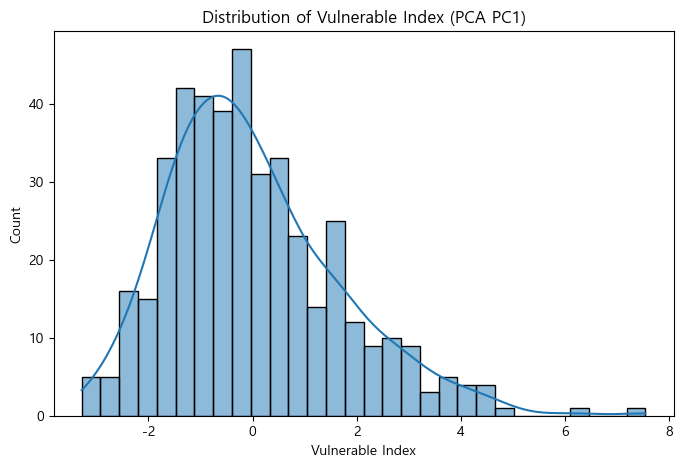

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_pca["vulnerable_index"], bins=30, kde=True)
plt.title("Distribution of Vulnerable Index (PCA PC1)")
plt.xlabel("Vulnerable Index")
plt.ylabel("Count")
plt.show()


# (검증 ②) 원 변수들과의 상관관계

In [49]:
import matplotlib as mpl
print("matplotlib font.family:", mpl.rcParams["font.family"])
print("matplotlib font.sans-serif:", mpl.rcParams.get("font.sans-serif"))


matplotlib font.family: ['Malgun Gothic']
matplotlib font.sans-serif: ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']


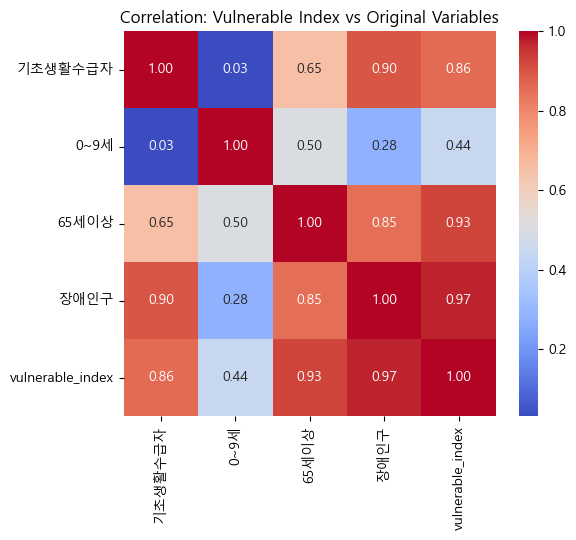

In [50]:
import sys
# Windows: 맑은 고딕 / Colab·리눅스: 나눔고딕 (한글 깨짐 방지)
mpl.rcParams["font.family"] = "Malgun Gothic" if sys.platform == "win32" else "Nanum Gothic"
mpl.rcParams["axes.unicode_minus"] = False

corr_cols = [
    "기초생활수급자",
    "0~9세",
    "65세이상",
    "장애인구",
    "vulnerable_index"
]

corr = df_pca[corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: Vulnerable Index vs Original Variables")
plt.show()


# (검증 ③) 상위 / 하위 행정동 비교

In [51]:
top = df_pca.sort_values("vulnerable_index", ascending=False).head(20)

top[["구별","동별",
     "기초생활수급자","0~9세","65세이상","장애인구",
     "vulnerable_index"]]


,구별,동별,기초생활수급자,0~9세,65세이상,장애인구,vulnerable_index
60,강서구,등촌3동,4390.0,1369,8205,3553.0,7.538499
150,노원구,중계2.3동,3629.0,1306,8478,2874.0,6.120533
326,양천구,신정3동,2268.0,2602,9408,2211.0,4.915866
374,은평구,역촌동,2122.0,1730,10233,2141.0,4.632375
413,중랑구,망우본동,2595.0,2636,8260,1993.0,4.592493
67,강서구,화곡1동,1859.0,1692,10223,2173.0,4.429315
13,강남구,세곡동,2070.0,3173,8108,2023.0,4.333992
379,은평구,진관동,1424.0,2965,10085,1916.0,4.176660
25,강동구,길동,1423.0,2136,10281,2050.0,4.089885
424,중랑구,신내1동,2177.0,1918,8408,1948.0,3.957903


In [52]:
bottom = df_pca.sort_values("vulnerable_index").head(20)

bottom[["구별","동별",
        "기초생활수급자","0~9세","65세이상","장애인구",
        "vulnerable_index"]]


,구별,동별,기초생활수급자,0~9세,65세이상,장애인구,vulnerable_index
401,중구,소공동,32.0,259,339,39.0,-3.279769
385,종로구,삼청동,36.0,93,641,102.0,-3.169382
405,중구,을지로동,135.0,138,524,89.0,-3.119490
400,중구,명동,51.0,101,802,104.0,-3.102054
380,종로구,가회동,61.0,146,906,168.0,-2.967062
409,중구,필동,104.0,129,962,178.0,-2.907381
406,중구,장충동,154.0,128,965,181.0,-2.860440
235,서초구,반포본동,309.0,17,40,491.0,-2.673680
397,중구,광희동,215.0,143,1287,207.0,-2.672854
390,종로구,종로5.6가동,252.0,148,1135,243.0,-2.641849


파일저장

In [53]:
save_path = "df_verIdx.csv"
df_pca.to_csv(output_path+save_path, index=False, encoding="utf-8-sig")

#공간 join __ 행정동 mapping


In [54]:
import re

# ── 1) 데이터 로드 ──
df_verIdx = pd.read_csv("../data_processed/processed/vulnerable/df_verIdx.csv")
grid_to_gu = pd.read_csv("../data_processed/processed/admin_mapping/grid_to_gu.csv")
grid_to_dong = pd.read_csv("../data_processed/processed/admin_mapping/grid_to_dong.csv")

# ── 2) 텍스트 정규화 함수 ──
def normalize_adm_nm(s: str) -> str:
    """공백·특수문자 정리"""
    s = str(s).strip()
    s = re.sub(r"\s+", "", s)
    s = re.sub(r"[·,]", ".", s)
    s = re.sub(r"\(.*?\)", "", s)
    return s

def normalize_gu_dong(df, gu_col="구별", dong_col="동별"):
    """구·동 표기 통일 (복사본 노트북 참조)"""
    df = df.copy()
    df[gu_col] = df[gu_col].astype(str).str.strip()
    df[dong_col] = df[dong_col].astype(str).str.strip()
    # 구 표준화: 동대문 → 동대문구
    df[gu_col] = df[gu_col].replace({"동대문": "동대문구"})
    # 동 표준화: 정능1~4동 → 정릉1~4동
    dong_map = {"정능1동": "정릉1동", "정능2동": "정릉2동",
                "정능3동": "정릉3동", "정능4동": "정릉4동"}
    df[dong_col] = df[dong_col].replace(dong_map)
    return df

# ── 3) df_verIdx 정규화 ──
df_verIdx = normalize_gu_dong(df_verIdx)
df_verIdx["동별"] = df_verIdx["동별"].map(normalize_adm_nm)

# ── 4) 용신동 처리: 용두동 + 신설동 → 용신동 (평균) ──
has_yongsin = ((df_verIdx["구별"] == "동대문구") & (df_verIdx["동별"] == "용신동")).any()
merge_adm = ["용두동", "신설동"]
mask = (df_verIdx["구별"] == "동대문구") & (df_verIdx["동별"].isin(merge_adm))

if not has_yongsin and mask.sum() > 0:
    # 용신동이 없으면 용두동+신설동 평균으로 생성
    mean_vul = df_verIdx.loc[mask, "vulnerable_index"].mean()
    new_row = pd.DataFrame([{"구별": "동대문구", "동별": "용신동", "vulnerable_index": mean_vul}])
    df_verIdx = pd.concat([df_verIdx[~mask], new_row], ignore_index=True)
    print(f"용신동 생성 (용두동+신설동 평균): vulnerable_index = {mean_vul:.4f}")
elif has_yongsin:
    # 용신동이 이미 있으면 용두동·신설동 제거만
    df_verIdx = df_verIdx[~mask].reset_index(drop=True)
    print("용신동 이미 존재 → 용두동·신설동 제거")

# ── 4-1) 구별+동별 중복 제거 (혹시 남은 중복 방지) ──
before = len(df_verIdx)
df_verIdx = df_verIdx.drop_duplicates(subset=["구별", "동별"], keep="first").reset_index(drop=True)
after = len(df_verIdx)
if before != after:
    print(f"중복 제거: {before} → {after}행")

# ── 5) grid 동 이름 정규화 ──
grid_to_dong = grid_to_dong.copy()
grid_to_dong["ADM_NM"] = grid_to_dong["ADM_NM"].map(normalize_adm_nm)

# ── 6) cell_id별 구·동 병합 ──
grid_admin = grid_to_gu[["cell_id", "SIGUNGU_NM"]].merge(
    grid_to_dong[["cell_id", "ADM_NM"]],
    on="cell_id",
    how="inner"
)

# ── 7) left merge: 모든 cell_id 유지 ──
df_verIdx_sub = df_verIdx[["구별", "동별", "vulnerable_index"]]
df_cell_vulnerable = grid_admin.merge(
    df_verIdx_sub,
    left_on=["SIGUNGU_NM", "ADM_NM"],
    right_on=["구별", "동별"],
    how="left"
)

# ── 8) 미매핑 cell: 같은 구 평균으로 채우기 ──
null_count_before = df_cell_vulnerable["vulnerable_index"].isna().sum()
gu_mean = df_cell_vulnerable.groupby("SIGUNGU_NM")["vulnerable_index"].transform("mean")
df_cell_vulnerable["vulnerable_index"] = df_cell_vulnerable["vulnerable_index"].fillna(gu_mean)
null_count_after = df_cell_vulnerable["vulnerable_index"].isna().sum()

# 구별·동별 컬럼 정리
df_cell_vulnerable["구별"] = df_cell_vulnerable["구별"].fillna(df_cell_vulnerable["SIGUNGU_NM"])
df_cell_vulnerable["동별"] = df_cell_vulnerable["동별"].fillna(df_cell_vulnerable["ADM_NM"])
df_cell_vulnerable = df_cell_vulnerable[["cell_id", "SIGUNGU_NM", "ADM_NM", "vulnerable_index"]]
df_cell_vulnerable.columns = ["cell_id", "구별", "동별", "vulnerable_index"]

print(f"\n전체 cell: {len(df_cell_vulnerable):,}")
print(f"구 평균으로 채운 cell: {null_count_before - null_count_after:,}")
print(f"최종 NaN 수: {null_count_after:,}")

용신동 이미 존재 → 용두동·신설동 제거

전체 cell: 92,398
구 평균으로 채운 cell: 9,555
최종 NaN 수: 0


In [55]:
# ── 매칭 검증 ──────────────────────────────────────────────

# 1) 기본 shape 확인
print("=" * 60)
print(f"[데이터 크기]")
print(f"  df_verIdx (취약계층)       : {df_verIdx.shape[0]}개 동")
print(f"  grid_admin (cell별 구·동)  : {grid_admin.shape[0]:,}개 cell")
print(f"  df_cell_vulnerable (결과)  : {df_cell_vulnerable.shape[0]:,}개 cell")
print()

# 2) NaN 확인
nan_count = df_cell_vulnerable["vulnerable_index"].isna().sum()
print(f"[NaN 현황]")
print(f"  vulnerable_index NaN : {nan_count:,}개")
print()

# 3) 매칭 안 된 동 확인 (정규화 후)
ver_pairs = set(zip(df_verIdx["구별"], df_verIdx["동별"]))
grid_pairs = set(zip(grid_admin["SIGUNGU_NM"], grid_admin["ADM_NM"]))

unmatched_ver = ver_pairs - grid_pairs
unmatched_grid = grid_pairs - ver_pairs

print(f"[구·동 매칭 결과]")
print(f"  매칭된 구·동 조합 수       : {len(ver_pairs & grid_pairs)}")
print(f"  df_verIdx에만 있는 구·동   : {len(unmatched_ver)}")
print(f"  grid에만 있는 구·동        : {len(unmatched_grid)}")
print()

if unmatched_ver:
    print("  [df_verIdx에만 있는 구·동]")
    for gu, dong in sorted(unmatched_ver):
        print(f"    {gu} - {dong}")
    print()

if unmatched_grid:
    print("  [grid에만 있는 구·동 (구 평균으로 채움)]")
    for gu, dong in sorted(unmatched_grid):
        print(f"    {gu} - {dong}")
    print()

# 4) 구별 cell 수 & NaN 수
print("=" * 60)
print("[구별 cell 수 / NaN 수]")
summary = df_cell_vulnerable.groupby("구별").agg(
    cell_count=("cell_id", "count"),
    nan_count=("vulnerable_index", lambda x: x.isna().sum())
)
print(summary.to_string())
print()

# 5) 결과 미리보기
print("=" * 60)
print("[결과 미리보기]")
df_cell_vulnerable.head(10)

[데이터 크기]
  df_verIdx (취약계층)       : 426개 동
  grid_admin (cell별 구·동)  : 92,398개 cell
  df_cell_vulnerable (결과)  : 92,398개 cell

[NaN 현황]
  vulnerable_index NaN : 0개

[구·동 매칭 결과]
  매칭된 구·동 조합 수       : 412
  df_verIdx에만 있는 구·동   : 14
  grid에만 있는 구·동        : 57

  [df_verIdx에만 있는 구·동]
    강동구 - 고덕1동
    강동구 - 고덕2동
    강동구 - 암사1동
    강동구 - 암사3동
    구로구 - 수궁동
    구로구 - 항동
    은평구 - 갈현1동
    은평구 - 갈현2동
    은평구 - 구산동
    은평구 - 불광2동
    은평구 - 수색동
    은평구 - 신사2동
    은평구 - 증산동
    은평구 - 진관동

  [grid에만 있는 구·동 (구 평균으로 채움)]
    강남구 - 복정동
    강남구 - 신촌동
    강남구 - 태평1동
    강남구 - 태평2동
    강남구 - 태평3동
    강동구 - 감북동
    강동구 - 교문1동
    강동구 - 덕풍1동
    강동구 - 덕풍2동
    강동구 - 미사1동
    강동구 - 미사3동
    강동구 - 초이동
    강동구 - 춘궁동
    강서구 - 고강1동
    강서구 - 고강본동
    관악구 - 과천동
    관악구 - 관양동
    관악구 - 부림동
    관악구 - 비산3동
    관악구 - 석수1동
    관악구 - 원문동
    광진구 - 교문1동
    구로구 - 광명1동
    구로구 - 광명2동
    구로구 - 광명3동
    구로구 - 광명4동
    구로구 - 광명5동
    구로구 - 광명6동
    구로구 - 광명7동
    구로구 - 철산1동
    구로구 - 철산2동
    구로구 - 철산4동
    구로구 - 하

,cell_id,구별,동별,vulnerable_index
0,1411415045163,강서구,공항동,1.587958
1,1411415045164,강서구,공항동,1.587958
2,1411415045165,강서구,공항동,1.587958
3,1411425045158,강서구,공항동,1.587958
4,1411425045159,강서구,공항동,1.587958
5,1411425045160,강서구,공항동,1.587958
6,1411425045161,강서구,공항동,1.587958
7,1411425045162,강서구,공항동,1.587958
8,1411425045163,강서구,공항동,1.587958
9,1411425045164,강서구,공항동,1.587958


In [56]:
# cell_id, vulnerable_index만 저장
output_path = "../data_processed/processed/vulnerable/"
save_path = "grid_cellid_vulnerable_index.csv"

df_cell_vulnerable[["cell_id", "vulnerable_index"]].to_csv(
    output_path + save_path, index=False, encoding="utf-8-sig"
)
print(f"저장 완료: {output_path}{save_path}")
print(f"총 {len(df_cell_vulnerable):,}행")

저장 완료: ../data_processed/processed/vulnerable/grid_cellid_vulnerable_index.csv
총 92,398행


In [58]:
df = pd.read_csv("../data_processed/processed/vulnerable/grid_cellid_vulnerable_index.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92398 entries, 0 to 92397
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cell_id           92398 non-null  int64  
 1   vulnerable_index  92398 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 1.4 MB
